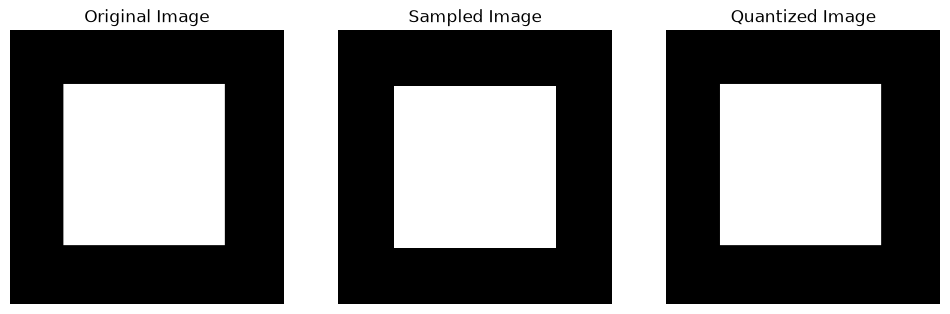

In [6]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

image_path = 'input.png'
if not os.path.exists(image_path):
    image_path = 'images/input.png'

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    original_image = np.zeros((256, 256), dtype=np.uint8)
    cv2.rectangle(original_image, (50, 50), (200, 200), 200, -1)

sampling_factor = 4
quantization_levels = 8

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

In [7]:
from PIL import Image
import numpy as np

img1 = Image.new('L', (400, 400), color=150)
img2 = Image.new('L', (400, 400), color=100)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

subtraction = cv2.subtract(im1arr, im2arr)
Image.fromarray(subtraction).show()

added_constant = cv2.add(im1arr, 175)
Image.fromarray(added_constant).show()

In [8]:
import numpy as np
from PIL import Image

arr1 = np.zeros((400, 400), dtype=np.uint8)
arr1[100:300, 100:300] = 255

arr2 = np.zeros((400, 400), dtype=np.uint8)
arr2[200:350, 200:350] = 255

intersection = cv2.bitwise_and(arr1, arr2)
Image.fromarray(intersection).show()

set_diff = cv2.subtract(arr1, arr2)
Image.fromarray(set_diff).show()

sym_diff = cv2.bitwise_xor(arr1, arr2)
Image.fromarray(sym_diff).show()